In [10]:
import xarray as xr 
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import matplotlib.dates as mdates

start_day = 6
end_day   = 30
dt = 10
isave = 360 # 6 
start_date = "2024-08-%02d 00:00" % start_day
end_date   = "2024-08-%02d 00:00" % end_day


dates = pd.date_range(start_date, end_date, freq="%ds" % dt)

model = xr.open_dataset("2024_June20.nc")

nt = len(model.time.values)
times = dates[::isave]
times = times[0:nt]

/tmp/ipykernel_1680746/3990031561.py:17: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  model = xr.open_dataset("2024_June20.nc")


In [11]:
# Load interpolated thermistor data
# Temperature 

fn = "/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/august6-28/interpolated_temperature_profile.feather"

thermistor = pd.read_feather(fn)
thermistor = thermistor.iloc[::isave, :]
thermistor = thermistor.iloc[0:nt, :]

print(thermistor.index)
# print(thermistor.index)

DatetimeIndex(['2024-08-06 00:00:00', '2024-08-06 01:00:00',
               '2024-08-06 02:00:00', '2024-08-06 03:00:00',
               '2024-08-06 04:00:00', '2024-08-06 05:00:00',
               '2024-08-06 06:00:00', '2024-08-06 07:00:00',
               '2024-08-06 08:00:00', '2024-08-06 09:00:00',
               ...
               '2024-08-27 13:00:00', '2024-08-27 14:00:00',
               '2024-08-27 15:00:00', '2024-08-27 16:00:00',
               '2024-08-27 17:00:00', '2024-08-27 18:00:00',
               '2024-08-27 19:00:00', '2024-08-27 20:00:00',
               '2024-08-27 21:00:00', '2024-08-27 22:00:00'],
              dtype='datetime64[ns]', length=527, freq=None)


model= (527,)
times= (527,)


(np.float64(19941.0), np.float64(19962.916666666668))

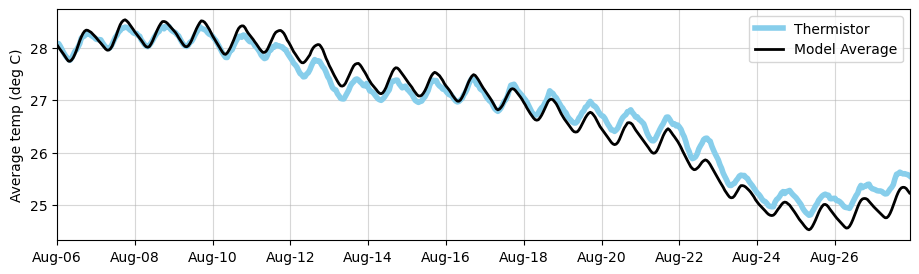

In [12]:
model_av = model.C.mean(dim='z').values

print("model=", model_av.shape)
print("times=", times.shape)
thermistor_av = thermistor.mean(axis=1).values


fig = plt.figure(figsize=(11, 3))
ax = fig.add_subplot(111)
plt.plot(thermistor.index, thermistor_av, label="Thermistor", color='skyblue', linewidth=4)
plt.plot(times, model_av, label="Model Average", color='black', linewidth=2)
ax.grid(alpha=0.5)
ax.set_ylabel("Average temp (deg C)")
ax.legend() 
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
ax.set_xlim(thermistor.index[0], thermistor.index[-1])


# print(model_av)


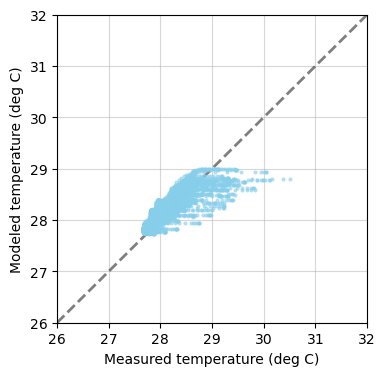

In [13]:
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111)

ax.set_xlim(26, 32)
ax.set_ylim(26, 32)
ax.plot([26, 32], [26, 32], '--',color='black',  linewidth=2, alpha=0.5)

for i in range(0, 100):
    ax.plot(thermistor.iloc[i,:], model.C.isel(time=i).values, '.', color="skyblue", alpha=0.5, markersize=4)
ax.set_xlabel("Measured temperature (deg C)")
ax.set_ylabel("Modeled temperature (deg C)")
ax.grid(alpha=0.5)


In [14]:
# rmse = [] 
# for i in range(1, nt-10):
#     rmse0 = np.sqrt((thermistor.iloc[i,:] - model.C.isel(time=i).values)**2)  
#     rmse.append(np.mean(rmse0))

# fig = plt.figure(figsize=(7,2)) 
# ax = fig.add_subplot(111)
# ax.plot(thermistor.index[0:-1], rmse[0:-1])
# ax.set_ylabel("RMSE (deg C)")
# ax.grid(alpha=0.5)
# ax.xaxis.set_major_locator(mdates.DayLocator(2))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))

2024-08-06 01:00:00


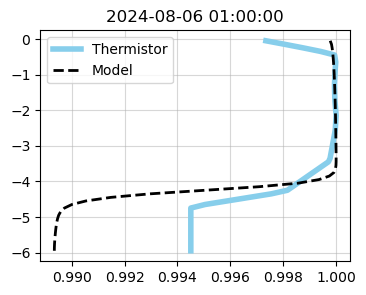

2024-08-06 11:00:00


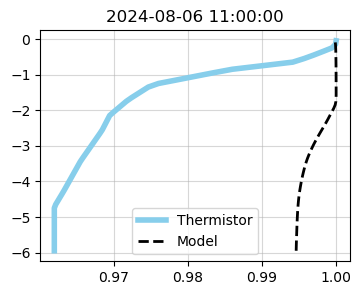

2024-08-06 21:00:00


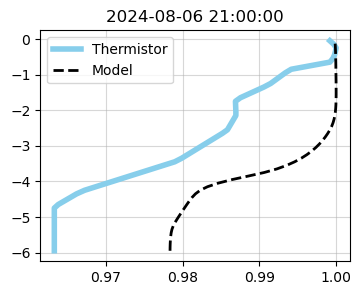

2024-08-07 07:00:00


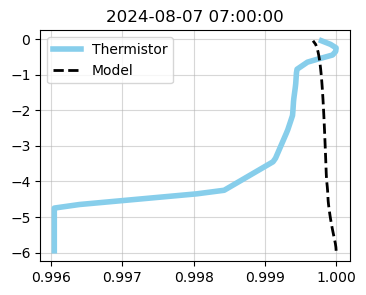

2024-08-07 17:00:00


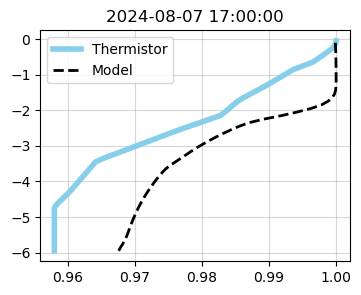

2024-08-08 03:00:00


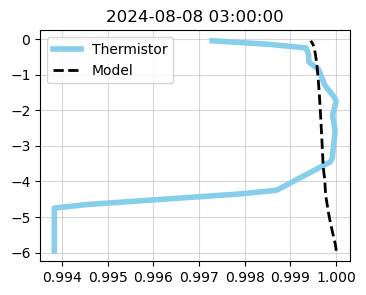

2024-08-08 13:00:00


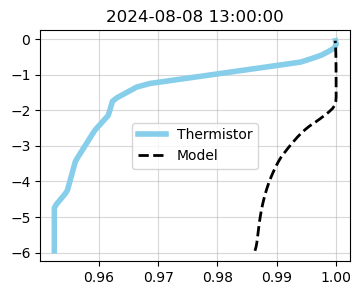

2024-08-08 23:00:00


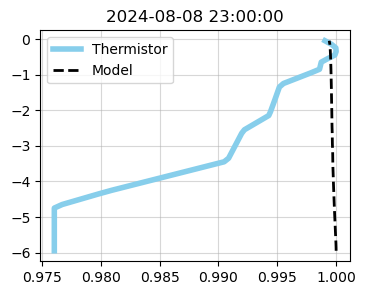

2024-08-09 09:00:00


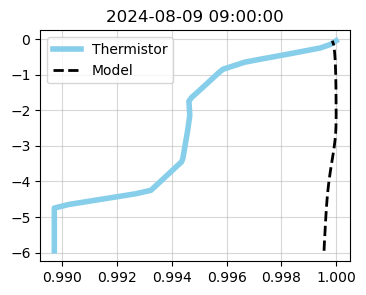

2024-08-09 19:00:00


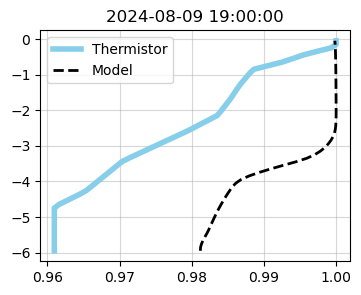

2024-08-10 05:00:00


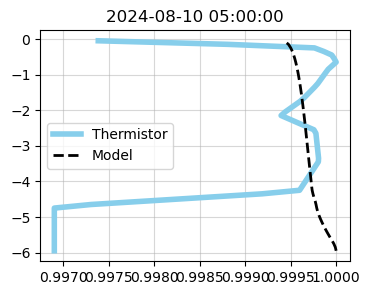

2024-08-10 15:00:00


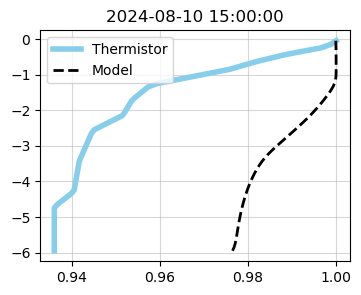

2024-08-11 01:00:00


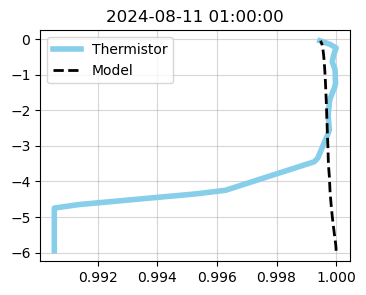

2024-08-11 11:00:00


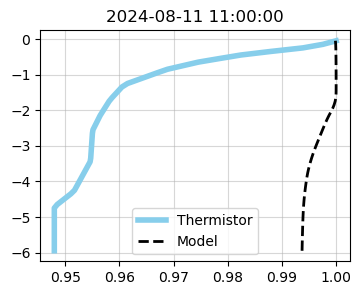

2024-08-11 21:00:00


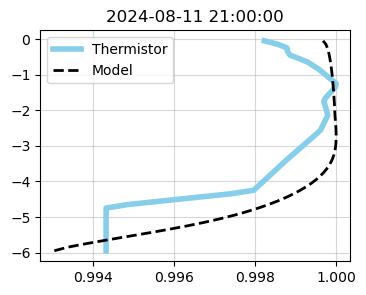

2024-08-12 07:00:00


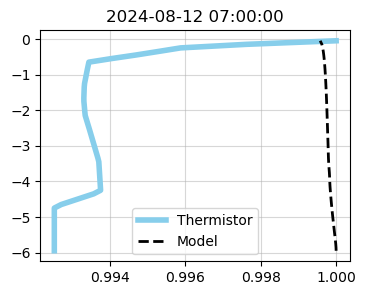

2024-08-12 17:00:00


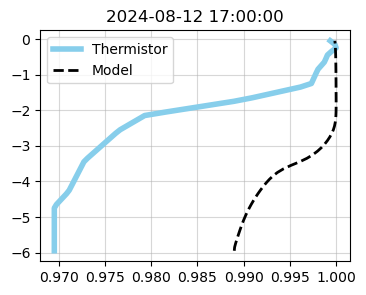

2024-08-13 03:00:00


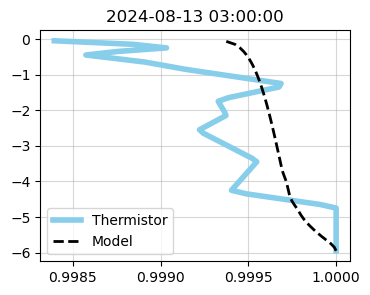

2024-08-13 13:00:00


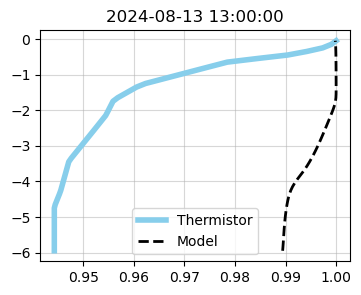

2024-08-13 23:00:00


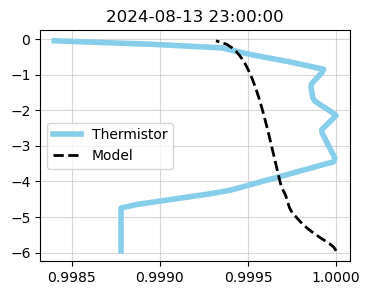

2024-08-14 09:00:00


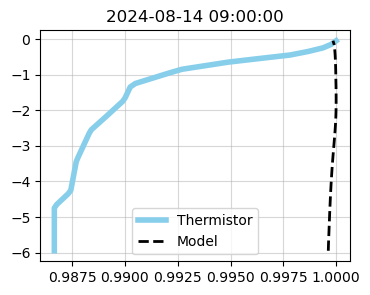

2024-08-14 19:00:00


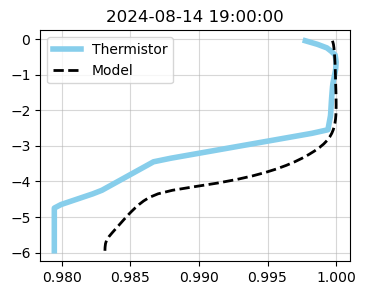

2024-08-15 05:00:00


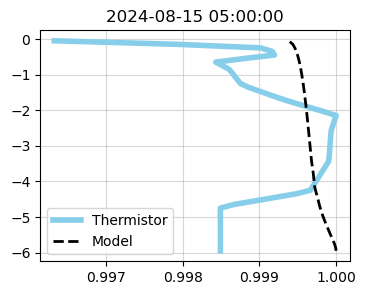

2024-08-15 15:00:00


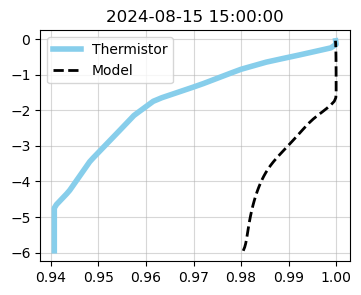

2024-08-16 01:00:00


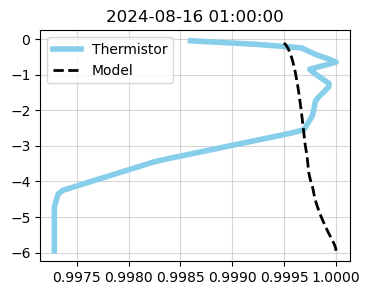

2024-08-16 11:00:00


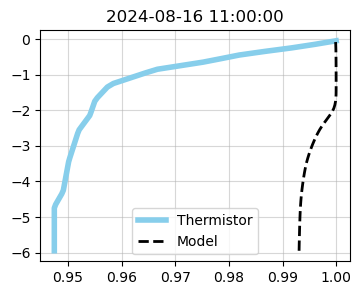

2024-08-16 21:00:00


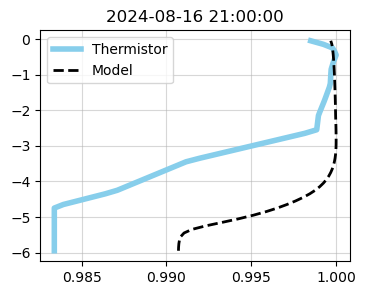

2024-08-17 07:00:00


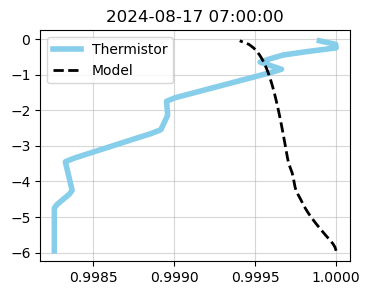

2024-08-17 17:00:00


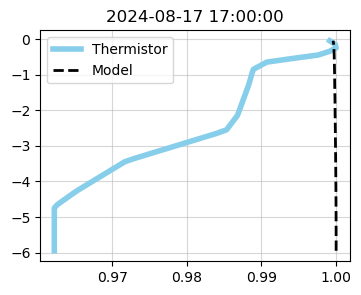

2024-08-18 03:00:00


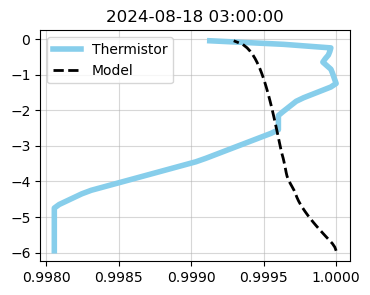

2024-08-18 13:00:00


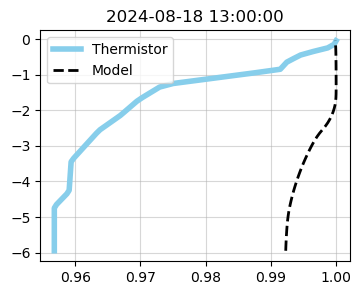

2024-08-18 23:00:00


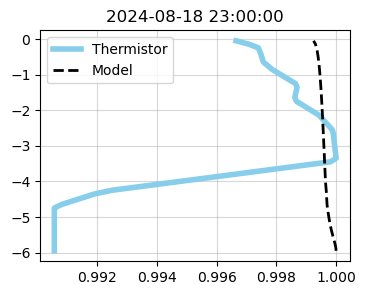

2024-08-19 09:00:00


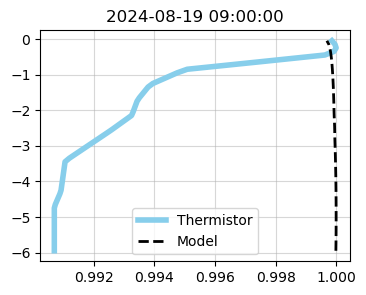

2024-08-19 19:00:00


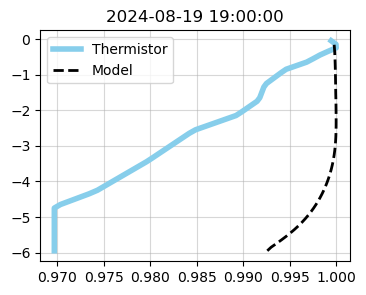

2024-08-20 05:00:00


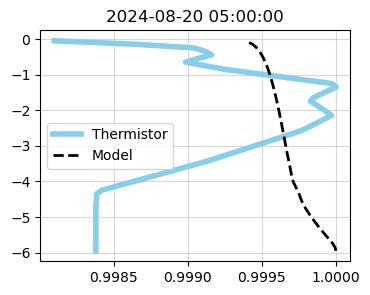

2024-08-20 15:00:00


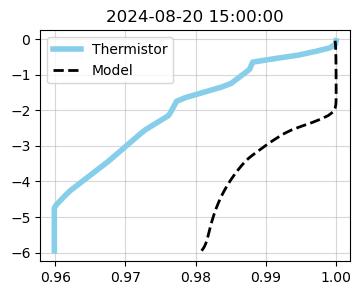

2024-08-21 01:00:00


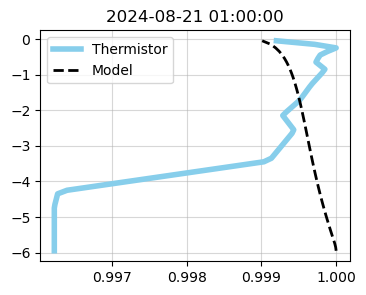

2024-08-21 11:00:00


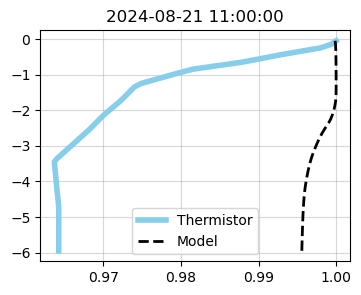

2024-08-21 21:00:00


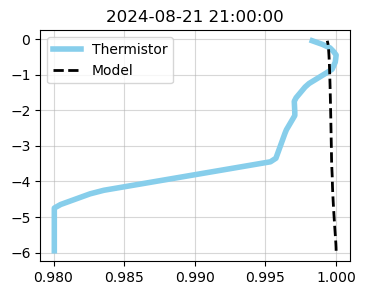

2024-08-22 07:00:00


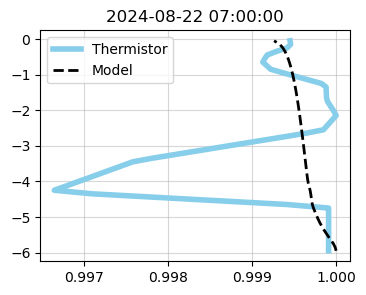

2024-08-22 17:00:00


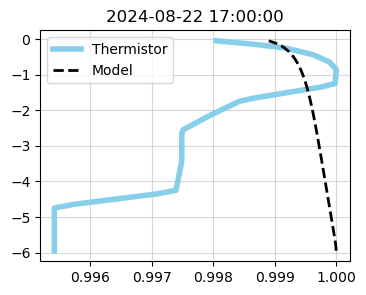

2024-08-23 03:00:00


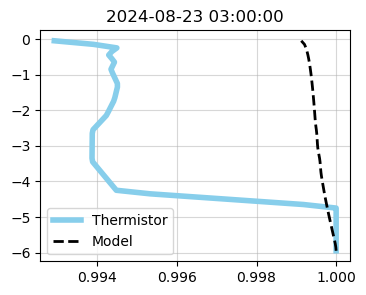

2024-08-23 13:00:00


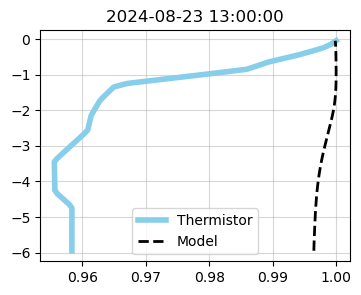

2024-08-23 23:00:00


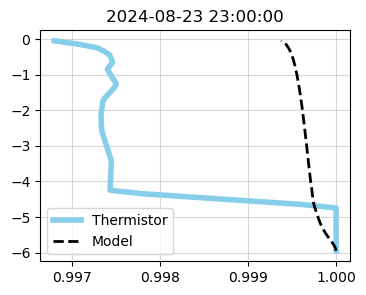

2024-08-24 09:00:00


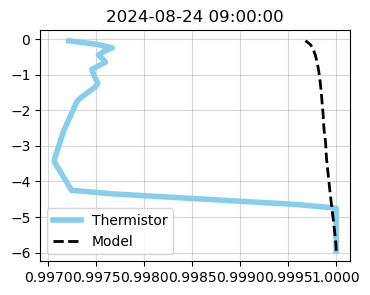

2024-08-24 19:00:00


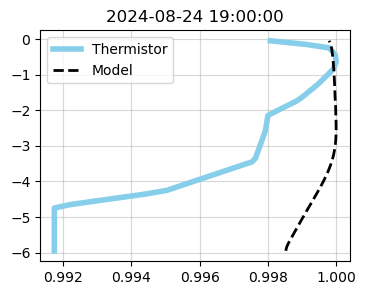

2024-08-25 05:00:00


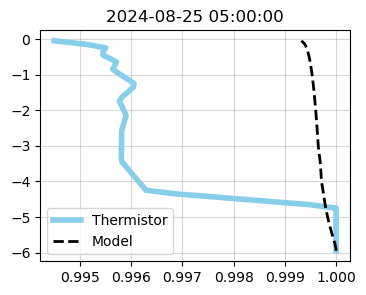

2024-08-25 15:00:00


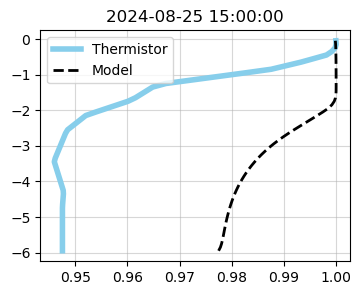

2024-08-26 01:00:00


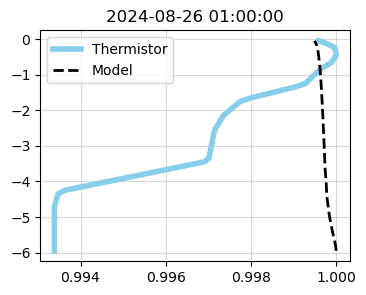

2024-08-26 11:00:00


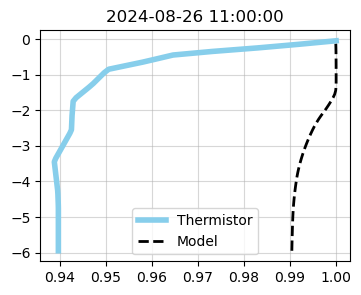

2024-08-26 21:00:00


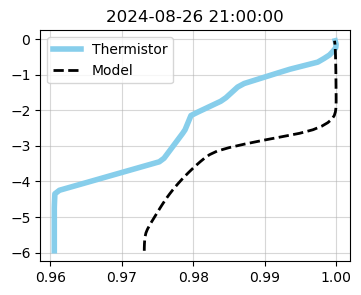

2024-08-27 07:00:00


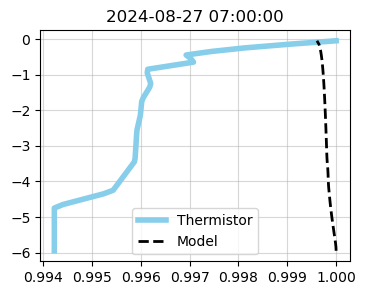

2024-08-27 17:00:00


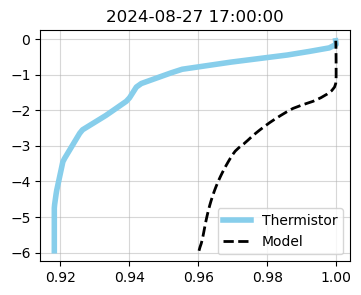

In [ ]:
z = model.z.values
import time 
# /max(thermistor.iloc[j, :])
# /max(model.C.isel(time=j).values)
for j in range(1,nt,10): 
    fig = plt.figure(figsize=(4,3)) 
    print(thermistor.index[j])
    plt.plot(thermistor.iloc[j, :], -z, label="Thermistor", color='skyblue', linewidth=4)
    plt.plot(model.C.isel(time=j).values, -z, '--', label="Model", color='black', linewidth=2)

    plt.title("%s" % thermistor.index[j])
    ax = plt.gca()
    ax.grid(alpha=0.5)
    ax.legend()
    plt.show()



In [16]:
string = ' ' 
for val in thermistor.iloc[0,:].values:
    string += ' %f,' % val
print(string)

  27.786400, 27.786400, 27.786400, 27.786400, 27.786400, 27.786400, 27.786400, 27.786400, 27.786400, 27.786400, 27.786400, 27.786400, 27.786400, 27.798220, 27.816607, 27.834993, 27.853380, 27.878350, 27.915170, 27.951990, 27.988810, 28.025630, 28.062450, 28.099270, 28.136090, 28.172910, 28.181460, 28.182300, 28.183140, 28.183980, 28.184820, 28.185660, 28.186500, 28.187340, 28.188050, 28.188283, 28.188517, 28.188750, 28.188983, 28.189087, 28.189180, 28.189273, 28.189367, 28.189280, 28.189093, 28.188907, 28.188720, 28.188400, 28.187840, 28.187280, 28.186720, 28.186233, 28.186700, 28.187167, 28.187027, 28.186840, 28.188853, 28.191467, 28.189520, 28.185040,


11.915697
2.75


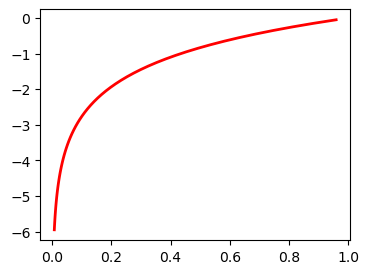

In [17]:
n1 = 1.2


adjustment = np.sum(np.exp(-z/n1)) 

print(adjustment)
# print(adjustment)400 * (10 * 1/adjustment * 
curve = (np.exp(-z/n1)) 

fig = plt.figure(figsize=(4,3))
plt.plot(curve, -z, label="n1 = %.2f" % n1, color='red', linewidth=2)

ind = sum(curve<0.1) 
print(z[ind])


In [18]:

# temp = pd.read_csv(fn, header=1)
# temp = temp.loc[temp['STAT'] == "Average"]
# temp["time"] = pd.to_datetime(temp["TIMESTAMP"])

# # PLZ
# temp_wp = temp[temp['SITE'] == 'WEB']
# temp_wp = temp_wp.groupby('time').mean()


# temp_up = temp[temp['SITE'] == 'PLZ']
# temp_up = temp_up.groupby('time').mean()

# temp_tb = temp[temp['SITE'] == 'TB']
# temp_tb = temp_tb.groupby('time').mean()
# Open feather file 